In [1]:
import os
import cv2
import time
import random
import numpy as np
import glob
import random
import shutil

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader

import torchvision.transforms as T
from torchvision.utils import make_grid
from torchvision.models import resnet50

from sklearn.model_selection import train_test_split

from PIL import Image

import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
DIR_TRAIN = "Datasets/Covid_Normal_Images/train/"
DIR_TEST = "Datasets/Covid_Normal_Images/test/"

In [24]:
for i in random.sample(glob.glob('Datasets/Covid_Normal_Images/COVID*'),500):
    shutil.move(i, 'Datasets/Covid_Normal_Images/train/')      
for i in random.sample(glob.glob('Datasets/Covid_Normal_Images/Normal*'), 500):
    shutil.move(i, 'Datasets/Covid_Normal_Images/train/')

for i in random.sample(glob.glob('Datasets/Covid_Normal_Images/COVID*'),100):
    shutil.move(i, 'Datasets/Covid_Normal_Images/test/')      
for i in random.sample(glob.glob('Datasets/Covid_Normal_Images/Normal*'), 100):
    shutil.move(i, 'Datasets/Covid_Normal_Images/test/')

In [3]:
imgs = os.listdir(DIR_TRAIN) 
test_imgs = os.listdir(DIR_TEST)

print(imgs[:5])
print(test_imgs[:5])

['COVID-2053.png', 'Normal-2362.png', 'COVID-1691.png', 'Normal-1297.png', 'Normal-1538.png']
['COVID-2215.png', 'COVID-2525.png', 'Normal-2584.png', 'COVID-2429.png', 'COVID-1025.png']


In [4]:
covid_list = [img for img in imgs if img.split("-")[0] == "COVID"]
normal_list = [img for img in imgs if img.split("-")[0] == "Normal"]

print("No of Covid Images: ",len(covid_list))
print("No of Normal Images: ",len(normal_list))

class_to_int = {"COVID" : 0, "Normal" : 1}
int_to_class = {0 : "COVID", 1 : "Normal"}

No of Covid Images:  500
No of Normal Images:  500


In [5]:
def get_train_transform():
    return T.Compose([
        T.Resize(64),
        T.ToTensor(),
        T.Normalize((0.5),(0.5))
    ])
    
def get_val_transform():
    return T.Compose([
        T.ToTensor(),
        T.Normalize((0.5),(0.5))
    ])

In [6]:
class Covid_Normal_Image(Dataset):
    
    def __init__(self, imgs, class_to_int, mode = "train", transforms = None):
        
        super().__init__()
        self.imgs = imgs
        self.class_to_int = class_to_int
        self.mode = mode
        self.transforms = transforms
        
    def __getitem__(self, idx):
        
        image_name = self.imgs[idx]
        
        img = Image.open(DIR_TRAIN + image_name)
        img = img.resize((64, 64))
        
        if self.mode == "train" or self.mode == "val":
        
            ### Preparing class label
            label = self.class_to_int[image_name.split("-")[0]]
            label = torch.tensor(label, dtype = torch.float32)

            ### Apply Transforms on image
            img = self.transforms(img)

            return img, label
        
        elif self.mode == "test":
            
            ### Apply Transforms on image
            img = self.transforms(img)

            return img
            
        
    def __len__(self):
        return len(self.imgs)
    

In [7]:
train_imgs, val_imgs = train_test_split(imgs, test_size = 0.25)

In [8]:
train_dataset = Covid_Normal_Image(train_imgs, class_to_int, mode = "train", transforms = get_train_transform())
val_dataset = Covid_Normal_Image(val_imgs, class_to_int, mode = "val", transforms = get_val_transform())
test_dataset = Covid_Normal_Image(test_imgs, class_to_int, mode = "test", transforms = get_val_transform())

train_data_loader = DataLoader(
    dataset = train_dataset,
    batch_size = 1,
    shuffle = True
)

val_data_loader = DataLoader(
    dataset = val_dataset,
    batch_size = 1,
    shuffle = True
)

test_data_loader = DataLoader(
    dataset = test_dataset,
    batch_size = 1,
    shuffle = True
)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


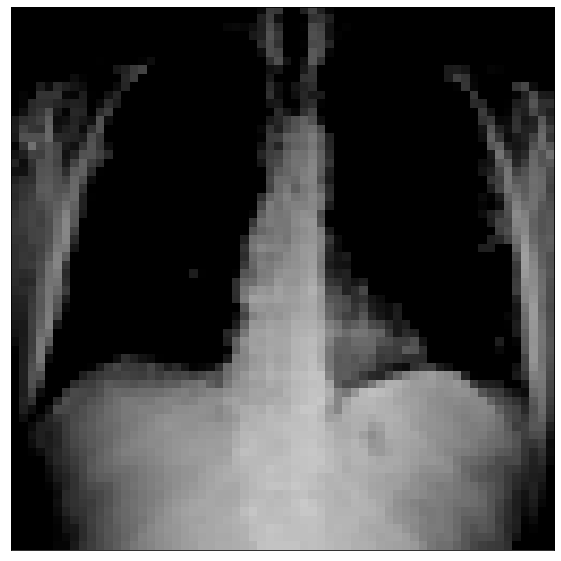

In [9]:
for images, labels in train_data_loader:
    fig, ax = plt.subplots(figsize = (10, 10))
    ax.set_xticks([])
    ax.set_yticks([])
    ax.imshow(make_grid(images, 4).permute(1,2,0))
    break

In [10]:
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

In [11]:
def accuracy(preds, trues):
    
    preds = [1 if preds[i] >= 0.5 else 0 for i in range(len(preds))]
    
    acc = [1 if preds[i] == trues[i] else 0 for i in range(len(preds))]
    
    acc = np.sum(acc) / len(preds)
    
    return (acc * 100)

In [12]:
def train_one_epoch(train_data_loader):
    
    ### Local Parameters
    epoch_loss = []
    epoch_acc = []
    start_time = time.time()
    
    ###Iterating over data loader
    for images, labels in train_data_loader:
        
        #Loading images and labels to device
        images = images.to(device)
        labels = labels.to(device)
        labels = labels.reshape((labels.shape[0], 1)) # [N, 1] - to match with preds shape
        
        #Reseting Gradients
        optimizer.zero_grad()
        
        #Forward
        preds = model(images)
        
        #Calculating Loss
        _loss = criterion(preds,labels)
        loss = _loss.item()
        epoch_loss.append(loss)
        
        #Calculating Accuracy
        acc = accuracy(preds, labels)
        epoch_acc.append(acc)
        
        #Backward
        _loss.backward()
        optimizer.step()
    
    ###Overall Epoch Results
    end_time = time.time()
    total_time = end_time - start_time
    
    ###Acc and Loss
    epoch_loss = np.mean(epoch_loss)
    epoch_acc = np.mean(epoch_acc)
    
    ###Storing results to logs
    train_logs["loss"].append(epoch_loss)
    train_logs["accuracy"].append(epoch_acc)
    train_logs["time"].append(total_time)
        
    return epoch_loss, epoch_acc, total_time

In [13]:
def val_one_epoch(val_data_loader, best_val_acc):
    
    ### Local Parameters
    epoch_loss = []
    epoch_acc = []
    start_time = time.time()
    
    ###Iterating over data loader
    for images, labels in val_data_loader:
        
        #Loading images and labels to device
        images = images.to(device)
        labels = labels.to(device)
        labels = labels.reshape((labels.shape[0], 1)) # [N, 1] - to match with preds shape
        
        #Forward
        preds = model(images)
        
        #Calculating Loss
        _loss = criterion(preds,labels)
        loss = _loss.item()
        epoch_loss.append(loss)
        
        #Calculating Accuracy
        acc = accuracy(preds, labels)
        epoch_acc.append(acc)
    
    ###Overall Epoch Results
    end_time = time.time()
    total_time = end_time - start_time
    
    ###Acc and Loss
    epoch_loss = np.mean(epoch_loss)
    epoch_acc = np.mean(epoch_acc)
    
    ###Storing results to logs
    val_logs["loss"].append(epoch_loss)
    val_logs["accuracy"].append(epoch_acc)
    val_logs["time"].append(total_time)
    
    ###Saving best model
    if epoch_acc > best_val_acc:
        best_val_acc = epoch_acc
        torch.save(model.state_dict(),"resnet50_best.pth")
        
    return epoch_loss, epoch_acc, total_time, best_val_acc

In [14]:
class Covid_Normal_CNN(nn.Module):
    
    def __init__(self):
        super(Covid_Normal_CNN, self).__init__()
        
        self.layer1 = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=16, kernel_size=1, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        
        self.layer2 = nn.Sequential(
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        
        self.fc1 = nn.Linear(in_features=8192, out_features=600)
        self.drop = nn.Dropout2d(0.25)
        self.fc2 = nn.Linear(in_features=600, out_features=1)
        self.Sigmoid = nn.Sigmoid()
        
    def forward(self, x):
        out = self.layer1(x)
        out = self.layer2(out)
        out = out.view(out.size(0), -1)
        out = self.fc1(out)
        out = self.drop(out)
        out = self.fc2(out)
        out = self.Sigmoid(out)
        
        return out

In [15]:
model = Covid_Normal_CNN()

In [16]:
optimizer = torch.optim.Adam(model.parameters(), lr = 0.0001)

criterion = nn.BCELoss()

train_logs = {"loss" : [], "accuracy" : [], "time" : []}
val_logs = {"loss" : [], "accuracy" : [], "time" : []}

model.to(device)

epochs = 15

In [17]:
best_val_acc = 0
for epoch in range(epochs):
    
    ###Training
    loss, acc, _time = train_one_epoch(train_data_loader)
    
    #Print Epoch Details
    print("\nTraining")
    print("Epoch {}".format(epoch+1))
    print("Loss : {}".format(round(loss, 4)))
    print("Acc : {}".format(round(acc, 4)))
    print("Time : {}".format(round(_time, 4)))
    
    ###Validation
    loss, acc, _time, best_val_acc = val_one_epoch(val_data_loader, best_val_acc)
    
    #Print Epoch Details
    print("\nValidating")
    print("Epoch {}".format(epoch+1))
    print("Loss : {}".format(round(loss, 4)))
    print("Acc : {}".format(round(acc, 4)))
    print("Time : {}".format(round(_time, 4)))
    


Training
Epoch 1
Loss : 0.9632
Acc : 68.2667
Time : 7.6997

Validating
Epoch 1
Loss : 0.6876
Acc : 73.6
Time : 1.3229

Training
Epoch 2
Loss : 0.49
Acc : 81.7333
Time : 6.3609

Validating
Epoch 2
Loss : 0.6339
Acc : 76.8
Time : 0.8861

Training
Epoch 3
Loss : 0.4286
Acc : 83.7333
Time : 5.3882

Validating
Epoch 3
Loss : 0.683
Acc : 75.6
Time : 0.8596

Training
Epoch 4
Loss : 0.4514
Acc : 84.2667
Time : 5.6443

Validating
Epoch 4
Loss : 0.714
Acc : 76.0
Time : 1.2037

Training
Epoch 5
Loss : 0.3511
Acc : 85.3333
Time : 6.2677

Validating
Epoch 5
Loss : 0.6123
Acc : 81.6
Time : 0.891

Training
Epoch 6
Loss : 0.3535
Acc : 86.1333
Time : 5.3338

Validating
Epoch 6
Loss : 0.7284
Acc : 78.8
Time : 0.9304

Training
Epoch 7
Loss : 0.302
Acc : 88.1333
Time : 5.4871

Validating
Epoch 7
Loss : 0.5601
Acc : 81.2
Time : 0.8981

Training
Epoch 8
Loss : 0.2488
Acc : 90.0
Time : 5.7598

Validating
Epoch 8
Loss : 0.6762
Acc : 78.8
Time : 0.9385

Training
Epoch 9
Loss : 0.2238
Acc : 90.6667
Time : 14.7

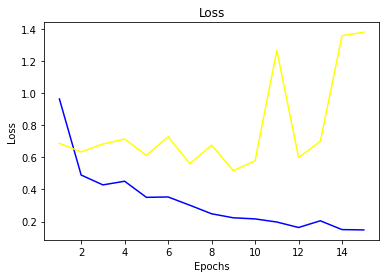

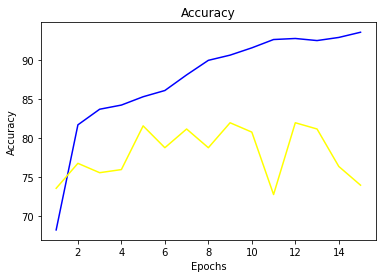

In [18]:
### Plotting Results

#Loss
plt.title("Loss")
plt.plot(np.arange(1, 16, 1), train_logs["loss"], color = 'blue')
plt.plot(np.arange(1, 16, 1), val_logs["loss"], color = 'yellow')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

#Accuracy
plt.title("Accuracy")
plt.plot(np.arange(1, 16, 1), train_logs["accuracy"], color = 'blue')
plt.plot(np.arange(1, 16, 1), val_logs["accuracy"], color = 'yellow')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.show()